# Sydney Housing Price Prediction and Decision Support System
**SIT307 Machine Learning: ML Mini Project (Distinction task)**
Author: Raghav · Data collected 30 Sep – 1 Oct 2026 from Domain.com.au

This notebook covers the full workflow: data collection and cleaning (Part 1), exploration and feature engineering (Part 2), model development with k-fold cross-validation (Part 3), analysis of the largest prediction failures (Part 4), and training and saving the model that the Flask web app serves (Part 5).

**How to run.** From the project folder: `pip install -r requirements.txt`, then open this notebook and choose *Restart & Run All* (or `jupyter nbconvert --to notebook --execute --inplace housing_price_prediction.ipynb`). Every random step uses `random_state=42`, so results are reproducible. A full run takes about 3–5 minutes on a laptop, mostly the nested cross-validation in Part 3.

---
# Part 1 — Problem definition and data collection

## 1.1 The prediction problem
A real estate agency wants a quick, evidence-based estimate of what a property will sell for, to support appraisals, pricing discussions with vendors, and sanity checks on buyer offers. The task is **supervised regression**: given a property's characteristics (suburb, dwelling type, bedrooms, bathrooms, parking, land size, sale method and sale date), predict its **sale price in AUD**.

Because the agency works across very different markets, a useful model needs to be accurate in *relative* terms: a \$100k error matters far more on a \$500k Penrith unit than on a \$5m Bondi house. I therefore model **log(price)** and judge models mainly on **mean absolute percentage error (MAPE)**, alongside MAE and RMSE in dollars.

## 1.2 Suburb selection and why
I picked three suburbs where I would genuinely consider buying, each a very different Sydney market:

| Suburb | Character | Why it interests me as a buyer |
|---|---|---|
| **Bondi** (2026) | Eastern-suburbs beachside, ~7 km from the CBD. Old terraces and semis, small art-deco walk-up flats, very high land values. | Lifestyle and the beach. The question is what a modest budget actually buys there. |
| **Parramatta** (2150) | Sydney's second CBD, ~23 km west. High-rise apartment towers around the centre, older freestanding houses on large blocks in the surrounding streets. | Strong jobs hub with the new light rail and Metro West; apartments are relatively affordable. |
| **Penrith** (2750) | Outer-west regional centre, ~50 km from the CBD at the foot of the Blue Mountains. Detached houses on large blocks, newer apartment precincts (e.g. Lord Sheffield Circuit). | Most affordable entry point, and the Western Sydney Airport will change the area. |

**How suburb characteristics should shape prices.** Location is expected to dominate: proximity to the CBD and the coast pushes Bondi land values far above the west. Within a suburb, **dwelling type** matters most, because a house includes the land while a unit only shares it. **Bedrooms and bathrooms** proxy for size, **land area** for redevelopment potential (relevant in Parramatta and Penrith), and the **sale method** (auctions are common for sought-after stock) and **sale date** (market movement) add smaller effects.

## 1.3 How the data were collected
I used the public *Sold listings* pages on **Domain.com.au** for each suburb, sorted by sale date, with the "exclude price withheld" filter, and recorded each sale's price, sale date, sale method, bedrooms, bathrooms, parking, area (where shown), property type and listing URL. I also opened individual listing pages to verify a sample of records. Collection was done in batches (one per results page) and merged with `data/build_dataset.py`, which keeps the raw values untouched so every cleaning decision is visible below.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import inspect, json, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import sklearn, joblib

import housing_features as hf

SEED = 42
np.random.seed(SEED)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

SUBURB_ORDER = ["Bondi", "Parramatta", "Penrith"]
SUBURB_COLORS = {"Bondi": "#2a6f97", "Parramatta": "#e07a1f", "Penrith": "#3a8d4f"}
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

def money(v):
    return f"${v:,.0f}"

PRICE_TICKS = [3e5, 5e5, 1e6, 2e6, 4e6, 6e6]

def price_axis(ax, axis="y"):
    # Readable dollar ticks on a log-scaled price axis
    a = ax.yaxis if axis == "y" else ax.xaxis
    (ax.set_yscale if axis == "y" else ax.set_xscale)("log")
    a.set_major_locator(mtick.FixedLocator(PRICE_TICKS))
    a.set_minor_locator(mtick.NullLocator())
    a.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e6:g}m" if v >= 1e6 else f"${v/1e3:.0f}k"))

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

print("Python", platform.python_version(), "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| seaborn", sns.__version__)

Python 3.11.15 | pandas 3.0.2 | scikit-learn 1.8.0 | seaborn 0.13.2


In [2]:
raw = pd.read_csv("data/sydney_sold_raw.csv", parse_dates=["sold_date"])
print(f"Raw records: {len(raw)} unique listing URLs")
print(raw.groupby("suburb").size().rename("records").to_string())
print(f"\nSale dates: {raw.sold_date.min():%d %b %Y} to {raw.sold_date.max():%d %b %Y}")
raw.head()

Raw records: 125 unique listing URLs
suburb
Bondi         39
Parramatta    38
Penrith       48

Sale dates: 27 Sep 2025 to 28 Sep 2026


,suburb,address,price,sold_date,sale_method,beds,baths,parking,area_m2,property_type,url,source_page,collected_on
0,Parramatta,2/16 Betts Street,660000,2026-09-12,private treaty,2,1,1.000,NaN,Apartment / Unit / Flat,https://www.domain.com.au/2-16-betts-street-pa...,"sold-listings (all types), page 1",2026-10-01
1,Parramatta,1404/1-3 Valentine Avenue,320000,2026-09-11,private treaty,1,1,0.000,NaN,Apartment / Unit / Flat,https://www.domain.com.au/1404-1-3-valentine-a...,"sold-listings (all types), page 1",2026-10-01
2,Parramatta,15/12 Early Street,493000,2026-09-11,private treaty,2,1,1.000,NaN,Apartment / Unit / Flat,https://www.domain.com.au/15-12-early-street-p...,"sold-listings (all types), page 1",2026-10-01
3,Parramatta,33/68 Great Western Highway,520000,2026-09-11,private treaty,2,1,1.000,NaN,Apartment / Unit / Flat,https://www.domain.com.au/33-68-great-western-...,"sold-listings (all types), page 1",2026-10-01
4,Parramatta,505/23 Hassall Street,660000,2026-09-09,private treaty,2,2,1.000,NaN,Apartment / Unit / Flat,https://www.domain.com.au/505-23-hassall-stree...,"sold-listings (all types), page 1",2026-10-01


## 1.4 Data quality audit
Before cleaning, I check what is missing, duplicated or suspicious.

In [3]:
audit = pd.DataFrame({
    "missing": raw.isna().sum(),
    "missing_%": (raw.isna().mean() * 100).round(1),
})
display(audit[audit.missing > 0])

# Same sale listed twice under two listing IDs (agent re-listed the property)
dup = raw[raw.duplicated(subset=["address", "sold_date", "price"], keep=False)]
print("Same address, date and price listed twice:")
display(dup[["suburb", "address", "price", "sold_date", "sale_method", "url"]])

print("Domain property-type labels:")
print(raw.property_type.value_counts().to_string())

,missing,missing_%
parking,3,2.400
area_m2,75,60.000


Same address, date and price listed twice:


,suburb,address,price,sold_date,sale_method,url
85,Bondi,4/11 Flood Street,1600000,2026-06-25,auction,https://www.domain.com.au/4-11-flood-street-bo...
86,Bondi,4/11 Flood Street,1600000,2026-06-25,private treaty,https://www.domain.com.au/4-11-flood-street-bo...


Domain property-type labels:
property_type
Apartment / Unit / Flat    62
House                      50
Retirement Living           4
Semi-detached               3
Townhouse                   3
Villa                       2
Duplex                      1


In [4]:
# Retirement-village sales: 37 Mulgoa Rd and 90 Lethbridge St, Penrith are retirement villages.
retire_mask = (raw.property_type.eq("Retirement Living")
               | raw.address.str.contains("37 Mulgoa Road|90 Lethbridge Street"))
print("Retirement-village sales:")
display(raw.loc[retire_mask, ["address", "price", "property_type", "beds", "area_m2"]])

# 'House' labels with a unit number in the address
mislabel = raw[raw.property_type.eq("House") & raw.address.str.contains("/")]
print("Labelled 'House' by Domain but with a unit number:")
display(mislabel[["suburb", "address", "price", "beds", "property_type"]])

# Implausible unit areas (whole strata site instead of the apartment)
units = raw.property_type.eq("Apartment / Unit / Flat")
print("Apartment 'areas' recorded on Domain (m²):")
print(raw.loc[units & raw.area_m2.notna(), ["address", "beds", "area_m2"]].to_string(index=False))

Retirement-village sales:


,address,price,property_type,beds,area_m2
102,49/37 Mulgoa Road,320000,Retirement Living,2,66.000
105,6/90 Lethbridge Street,640000,Retirement Living,2,NaN
108,24/37 Mulgoa Road,290000,Retirement Living,2,79.000
109,29/37 Mulgoa Road,435000,House,2,NaN
117,5/90 Lethbridge Street,581000,Retirement Living,2,NaN
124,94/37 Mulgoa Road,325000,Apartment / Unit / Flat,2,NaN


Labelled 'House' by Domain but with a unit number:


,suburb,address,price,beds,property_type
71,Bondi,9/27 Castlefield Street,1520000,2,House
75,Bondi,5/9-11 Ocean Street North,1445000,2,House
98,Penrith,37/132 Lethbridge Street,485000,2,House
109,Penrith,29/37 Mulgoa Road,435000,2,House


Apartment 'areas' recorded on Domain (m²):
                       address  beds   area_m2
               10/4 Peace Lane     2   108.000
 107/60 Lord Sheffield Circuit     1    79.000
 513/60 Lord Sheffield Circuit     1    61.000
 206/60 Lord Sheffield Circuit     2   109.000
105/81C Lord Sheffield Circuit     2   149.000
           510/10 Aviators Way     2   115.000
        1010/6 River Road West     2   126.000
               22/4 Peace Lane     2   101.000
           3/8 Fletcher Street     2    80.000
 405/2C Lord Sheffield Circuit     1    79.000
           17/171 Derby Street     2 2,364.000
       6/19-21 Thurston Street     2 1,751.000
          110/115 Derby Street     1    61.000


### Quality issues, challenges and sources of bias

**Missing information.** Area is missing for about 60% of records. Domain shows land area only when the agent enters it, and for apartments the field mixes internal floor area with the size of the whole strata site (two 2-bed flats show 1,751 m² and 2,364 m², clearly the building's land). Parking was absent for 3 Bondi houses.

**Errors in the source.** Domain labels some strata apartments as "House": 9/27 Castlefield St is described by its agent as a top-floor apartment. One Bondi sale (4/11 Flood St) appears twice under two listing IDs. Four retirement-village units (37 Mulgoa Rd, 90 Lethbridge St) sell under leasehold or licence arrangements, so their prices are not comparable freehold market values.

**Challenges in collection.** About half of all sales on Domain have *price withheld*, so I filtered to disclosed prices. Search pages sometimes disagreed with the listing page (344 Birrell St showed "Price Withheld" in the search grid but $5.86m on its own page), so I spot-checked records against individual listing pages; all four checks matched exactly. Results pages are capped, so to get enough houses I also used the "house" and "apartment" filtered pages.

**Potential bias and limits on validity.**
- *Selection bias from withheld prices.* Vendors withhold prices more often for disappointing results or prestige sales, so the dataset may under-represent both tails.
- *Sampling design.* I deliberately pulled house pages to balance the mix, so the house/unit ratio does not reflect each suburb's true sales mix. Suburb medians computed here are not market medians.
- *Different time windows.* Bondi and Parramatta houses sell less often, so their records go back further (to Sep 2025) than Penrith units (Jun–Sep 2026). Time and suburb are partly confounded.
- *Small sample.* ~118 usable sales means every estimate has wide uncertainty, and rare property types (townhouses, villas, dual-occupancy) have only a handful of examples.
- *Missing value drivers.* Condition, renovation, views, floor level, aspect, street quality and strata levies are not captured at all.

In [5]:
log = [("Raw records (unique URLs)", len(raw))]
df = raw.copy()

df = df.drop_duplicates(subset=["address", "sold_date", "price"], keep="first")
log.append(("Drop duplicate listing of the same sale", len(df)))

df = df[~(df.property_type.eq("Retirement Living")
          | df.address.str.contains("37 Mulgoa Road|90 Lethbridge Street"))]
log.append(("Drop retirement-village (leasehold) sales", len(df)))

df = df.reset_index(drop=True)
cleaning_log = pd.DataFrame(log, columns=["step", "rows remaining"])
display(cleaning_log)

df.to_csv("data/sydney_sold_clean.csv", index=False)
counts = df.suburb.value_counts().reindex(SUBURB_ORDER)
print(counts.to_string())
assert len(df) >= 100 and counts.min() >= 30, "Brief requires >=100 sales and >=30 per suburb"
print(f"\nRequirement met: {len(df)} sales, minimum {counts.min()} per suburb.")

,step,rows remaining
0,Raw records (unique URLs),125
1,Drop duplicate listing of the same sale,124
2,Drop retirement-village (leasehold) sales,118


suburb
Bondi         38
Parramatta    38
Penrith       42

Requirement met: 118 sales, minimum 38 per suburb.


Mislabelled property types and implausible unit areas are **not** dropped; they are corrected during feature engineering (Part 2), because the sale itself is valid. Outliers are examined in Part 2 and kept unless they are data errors.

---
# Part 2 — Data understanding and feature engineering

In [6]:
df["dwelling_class"] = [hf.dwelling_class(t, a) for t, a in zip(df.property_type, df.address)]

summary = (df.groupby(["suburb", "dwelling_class"]).price
             .agg(n="count", median="median", mean="mean", min="min", max="max")
             .reindex(SUBURB_ORDER, level=0))
summary.style.format({c: "${:,.0f}" for c in ["median", "mean", "min", "max"]})

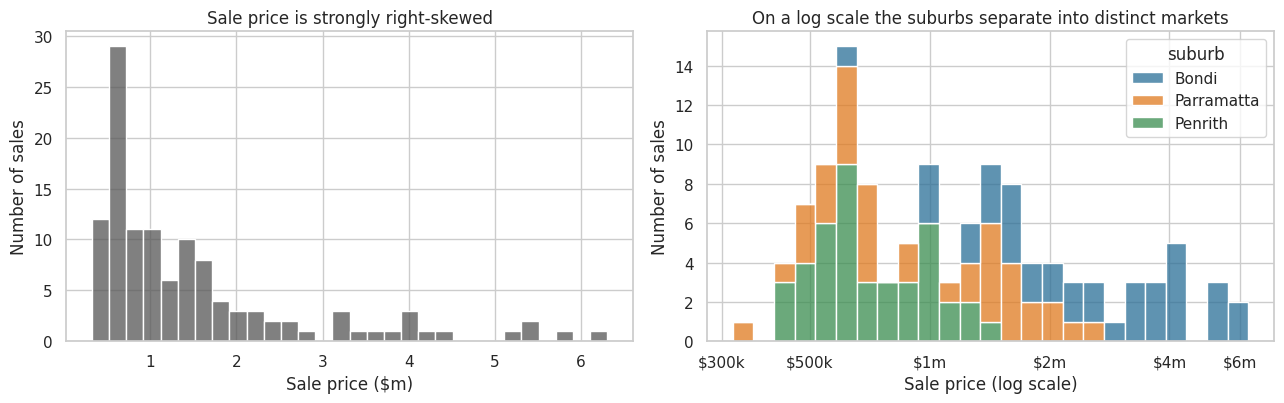

Skewness of price: 1.81  |  skewness of log(price): 0.57


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(df.price / 1e6, bins=30, ax=axes[0], color="#555")
axes[0].set(title="Sale price is strongly right-skewed", xlabel="Sale price ($m)", ylabel="Number of sales")
sns.histplot(data=df, x=np.log10(df.price), hue="suburb", hue_order=SUBURB_ORDER,
             palette=SUBURB_COLORS, bins=25, multiple="stack", ax=axes[1])
ticks = [3e5, 5e5, 1e6, 2e6, 4e6, 6e6]
axes[1].set_xticks(np.log10(ticks), ["$300k", "$500k", "$1m", "$2m", "$4m", "$6m"])
axes[1].set(title="On a log scale the suburbs separate into distinct markets", xlabel="Sale price (log scale)", ylabel="Number of sales")
plt.tight_layout(); save(fig, "fig1_price_distribution"); plt.show()

print(f"Skewness of price: {df.price.skew():.2f}  |  skewness of log(price): {np.log(df.price).skew():.2f}")

**Distribution.** Prices run from about \$320k to \$6.3m with a long right tail (skewness above 1.5). On a log scale the distribution is much more symmetric and clearly multi-modal, roughly one cluster per suburb and dwelling type. This motivates modelling **log(price)**: errors become proportional, the Bondi houses no longer dominate the loss, and linear relationships become plausible.

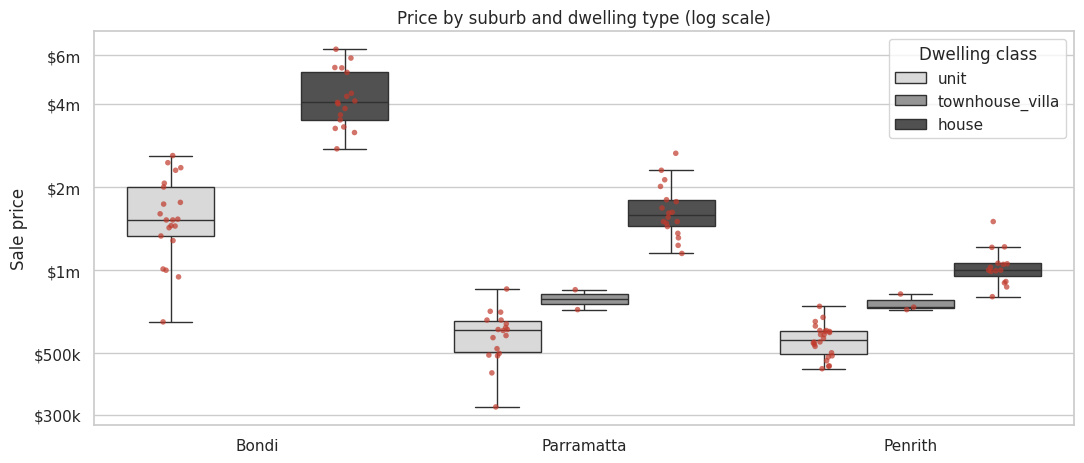

Median house price / median unit price:
suburb
Bondi        2.660
Parramatta   2.600
Penrith      1.790


In [8]:
fig, ax = plt.subplots(figsize=(11, 4.8))
order = ["unit", "townhouse_villa", "house"]
sns.boxplot(data=df, x="suburb", y="price", hue="dwelling_class", order=SUBURB_ORDER,
            hue_order=order, ax=ax, showfliers=False, palette="Greys")
sns.stripplot(data=df, x="suburb", y="price", hue="dwelling_class", order=SUBURB_ORDER,
              hue_order=order, dodge=True, ax=ax, palette={c: "#c0392b" for c in order}, size=4, alpha=.7, legend=False)
price_axis(ax)
ax.set(title="Price by suburb and dwelling type (log scale)", xlabel="", ylabel="Sale price")
ax.legend(title="Dwelling class", loc="upper right")
plt.tight_layout(); save(fig, "fig2_suburb_type"); plt.show()

ratio = df.groupby(["suburb", "dwelling_class"]).price.median().unstack()
print("Median house price / median unit price:")
print((ratio["house"] / ratio["unit"]).reindex(SUBURB_ORDER).round(2).to_string())

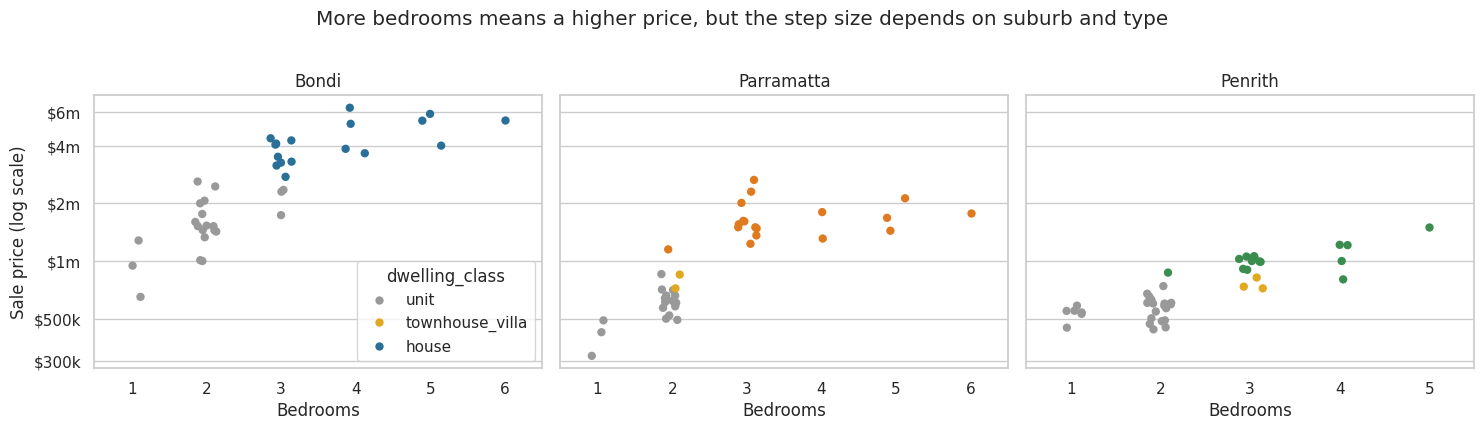

Spearman correlation with price, within each suburb:
            beds  baths  parking
Bondi      0.890  0.770    0.610
Parramatta 0.870  0.360    0.660
Penrith    0.820  0.510    0.510


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, sub in zip(axes, SUBURB_ORDER):
    d = df[df.suburb == sub]
    sns.stripplot(data=d, x="beds", y="price", hue="dwelling_class", hue_order=order,
                  ax=ax, jitter=.15, size=6, palette={"unit": "#999", "townhouse_villa": "#e0a91f", "house": SUBURB_COLORS[sub]})
    price_axis(ax); ax.set_title(sub); ax.set_xlabel("Bedrooms")
    if ax is not axes[0]: ax.get_legend().remove()
axes[0].set_ylabel("Sale price (log scale)")
fig.suptitle("More bedrooms means a higher price, but the step size depends on suburb and type", y=1.02)
plt.tight_layout(); save(fig, "fig3_beds"); plt.show()

print("Spearman correlation with price, within each suburb:")
corr = pd.DataFrame({s: df[df.suburb == s][["beds", "baths", "parking"]].corrwith(df[df.suburb == s].price, method="spearman")
                     for s in SUBURB_ORDER}).T
print(corr.round(2).to_string())

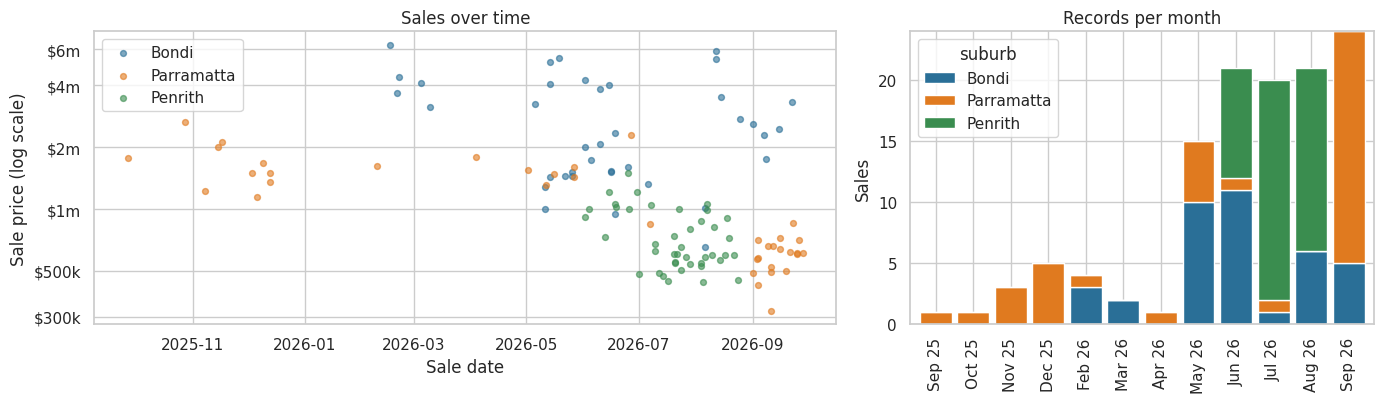

Within-segment trend: -0.15% per month (about -1.8% per year)


In [10]:
df["month"] = df.sold_date.dt.to_period("M").dt.to_timestamp()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
for sub in SUBURB_ORDER:
    d = df[df.suburb == sub]
    axes[0].scatter(d.sold_date, d.price, s=18, alpha=.6, color=SUBURB_COLORS[sub], label=sub)
price_axis(axes[0])
axes[0].set(title="Sales over time", ylabel="Sale price (log scale)", xlabel="Sale date")
axes[0].legend()
counts_m = df.groupby(["month", "suburb"]).size().unstack(fill_value=0).reindex(columns=SUBURB_ORDER)
counts_m.index = counts_m.index.strftime("%b %y")
counts_m.plot(kind="bar", stacked=True, ax=axes[1], color=[SUBURB_COLORS[s] for s in SUBURB_ORDER], width=.85)
axes[1].set(title="Records per month", xlabel="", ylabel="Sales")
plt.tight_layout(); save(fig, "fig4_time"); plt.show()

# Within-segment time trend: regress log price on months since start, inside each suburb x class cell
tmp = df.assign(t=hf.engineer_features(df).months_since_start, lp=np.log(df.price))
tmp["resid"] = tmp.lp - tmp.groupby(["suburb", "dwelling_class"]).lp.transform("mean")
slope = np.polyfit(tmp.t, tmp.resid, 1)[0]
print(f"Within-segment trend: {100*(np.exp(slope)-1):+.2f}% per month "
      f"(about {100*(np.exp(12*slope)-1):+.1f}% per year)")

**Trends over time.** The window runs from Sep 2025 to Sep 2026, but records are not spread evenly. Most come from Jun–Sep 2026, and the earlier ones are almost all Bondi and Parramatta *houses*, because houses sell less often and the house-filtered pages reach further back. A naive scatter of price against date therefore mixes market movement with changes in what was sold. Comparing each sale with its own suburb × dwelling-class average removes most of that composition effect, and the remaining trend is essentially flat (about −0.15% per month, −1.8% per year). Over this window, prices were broadly stable; `months_since_start` is still offered to the models, but any strong time effect a model learns is more likely to be composition than true market movement (revisited in Part 3).

In [11]:
# Outliers: robust z-score of log price within each suburb x dwelling-class segment
lp = np.log(df.price)
grp = df.groupby(["suburb", "dwelling_class"])
med = grp.price.transform(lambda s: np.log(s).median())
mad = grp.price.transform(lambda s: (np.log(s) - np.log(s).median()).abs().median())
df["robust_z"] = (lp - med) / (1.4826 * mad.replace(0, np.nan))
outliers = df[df.robust_z.abs() > 2.5].sort_values("robust_z")
display(outliers[["suburb", "address", "dwelling_class", "beds", "baths", "area_m2", "price", "robust_z"]])

,suburb,address,dwelling_class,beds,baths,area_m2,price,robust_z
1,Parramatta,1404/1-3 Valentine Avenue,unit,1,1,NaN,320000,-3.731
18,Bondi,7/162 Bondi Road,unit,1,1,NaN,650000,-3.334
25,Penrith,8 Cudgee Road,house,4,2,390.000,802000,-2.554
58,Parramatta,1 Irving Street,house,3,2,942.000,2650000,2.879
21,Penrith,5/90-92 Cox Avenue,townhouse_villa,3,2,NaN,820000,3.580
100,Penrith,31 & 31A Bel-air Road,house,5,4,558.000,1500000,4.693


**Unusual observations.** A robust z-score (median and MAD of log price within each suburb × dwelling class) flags six sales:
- **1404/1-3 Valentine Ave, Parramatta ($320k):** a unit in the *Mantra* hotel building, marketed on short-stay rental yield. A different asset class from an ordinary flat.
- **7/162 Bondi Rd ($650k):** a 1-bed walk-up with no parking, at the bottom of the Bondi unit market.
- **8 Cudgee Rd, Penrith ($802k):** a 4-bed house on a comparatively small 390 m² block.
- **1 Irving St, Parramatta ($2.65m):** a 942 m² block with pool and redevelopment appeal (confirmed on the listing page).
- **5/90-92 Cox Ave, Penrith ($820k):** a townhouse. It is flagged mainly because the townhouse/villa group has only 3 Penrith sales, so its MAD is tiny.
- **31 & 31A Bel-air Rd, Penrith ($1.5m):** a dual-occupancy sale (two dwellings on one title).

**Decision: all six are kept.** They are genuine sales, not data errors, and removing them would make cross-validation look better while hiding exactly the kinds of property the model will struggle with in practice. They are revisited in Part 4.

## 2.2 Hypothesis: the three most influential variables (stated before feature engineering)

1. **Suburb (location).** Land value is the biggest component of Sydney property prices, and land value is set by location: CBD access, coast, schools, amenity. Figure 2 shows medians differing several-fold between suburbs for the same dwelling type.
2. **Dwelling type (house vs unit).** A house includes its own land; a unit shares a strata lot. In land-scarce Bondi this should create a huge gap, and a smaller one in Penrith.
3. **Number of bedrooms.** The best available proxy for internal size, which we do not have directly. Within each suburb, price rises steadily with bedrooms (Figure 3).

I expect bathrooms and parking to matter, but mostly as correlated size signals (they overlap with bedrooms), and land area to matter for houses but to be limited by missing values.

## 2.3 Feature engineering
The engineered features (code below, shared with the web app via `housing_features.py`):

| Feature | Reason |
|---|---|
| `dwelling_class` (house / townhouse_villa / unit) | Collapses Domain's 6 labels into classes with enough examples, and **corrects mislabels**: a "House" with a unit number becomes a unit. |
| `segment` = suburb × dwelling class | The house premium differs hugely by suburb (Figure 2), which a purely additive linear model cannot represent otherwise. Built inside the pipeline. |
| `land_area_m2` + `land_area_known` | Land size only for houses/townhouses; unit "areas" set to missing because they mix floor area and site area. The flag lets models learn whether missingness itself carries signal. Missing values are imputed with the median *inside* each CV fold to avoid leakage. |
| `baths_per_bed` | Separates well-appointed homes (ensuites) from older stock with the same bed count. |
| `is_auction` | Auctions (and sales "prior to auction") are used for in-demand properties. |
| `months_since_start` | Captures market movement over the 13-month window. |

I did **not** add "distance to CBD": with only three suburbs it is a perfect relabelling of the suburb indicator and adds no information. It would become valuable with many suburbs.

In [12]:
print(inspect.getsource(hf.engineer_features))
X = hf.engineer_features(df)
y = df.price.values
print("Feature matrix:", X.shape)
X.head()

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Turn cleaned listing rows into model-ready features.

    Expects columns: suburb, property_type, address, beds, baths, parking,
    area_m2, sale_method, sold_date. Works for one row (the app) or many.
    """
    out = pd.DataFrame(index=df.index)
    out["suburb"] = df["suburb"].astype(str)
    out["dwelling_class"] = [dwelling_class(t, a)
                             for t, a in zip(df["property_type"], df["address"])]

    out["beds"] = pd.to_numeric(df["beds"], errors="coerce")
    out["baths"] = pd.to_numeric(df["baths"], errors="coerce")
    out["parking"] = pd.to_numeric(df["parking"], errors="coerce")
    out["baths_per_bed"] = out["baths"] / out["beds"].clip(lower=1)

    # Land area only means something for land-holding dwellings. Unit "areas"
    # on Domain are a mix of internal floor area and the whole strata site
    # (we saw 1,751 m2 and 2,364 m2 for 2-bed flats), so they are dropped.
    area = pd.to_num

,beds,baths,parking,land_area_m2,baths_per_bed,months_since_start,is_auction,land_area_known,suburb,dwelling_class
0,2,1,1.000,NaN,0.500,12.000,0,0,Parramatta,unit
1,1,1,0.000,NaN,1.000,12.000,0,0,Parramatta,unit
2,2,1,1.000,NaN,0.500,12.000,0,0,Parramatta,unit
3,2,1,1.000,NaN,0.500,12.000,0,0,Parramatta,unit
4,2,2,1.000,NaN,1.000,12.000,0,0,Parramatta,unit


In [13]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, RepeatedKFold, cross_validate, cross_val_predict, GridSearchCV, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

def preprocessor(scale_numeric):
    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scale", StandardScaler()))
    return Pipeline([
        ("segment", FunctionTransformer(hf.add_segment)),
        ("columns", ColumnTransformer([
            ("num", Pipeline(num_steps), hf.NUMERIC_FEATURES),
            ("bin", "passthrough", hf.BINARY_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
             hf.CATEGORICAL_FEATURES + ["segment"]),
        ], verbose_feature_names_out=False)),
    ])

def log_target(pipe):
    # Fit on log(price), predict back in dollars, so every metric is in $ terms
    return TransformedTargetRegressor(regressor=pipe, func=np.log, inverse_func=np.exp)

SCORING = {"MAPE": "neg_mean_absolute_percentage_error", "MAE": "neg_mean_absolute_error",
           "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

In [14]:
# Does feature engineering help? Same Ridge model, raw vs engineered inputs, 5-fold CV x 3 repeats.
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)

raw_cols = ["suburb", "property_type", "beds", "baths", "parking"]
X_rawfeat = df[raw_cols].copy()
X_rawfeat["parking"] = X_rawfeat.parking.fillna(X_rawfeat.parking.median())
raw_ridge = log_target(Pipeline([
    ("columns", ColumnTransformer([
        ("num", StandardScaler(), ["beds", "baths", "parking"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["suburb", "property_type"])])),
    ("model", Ridge(alpha=1.0))]))
eng_ridge = log_target(Pipeline([("prep", preprocessor(True)), ("model", Ridge(alpha=1.0))]))

rows = []
for name, model, data in [("Ridge, raw Domain fields", raw_ridge, X_rawfeat),
                          ("Ridge, engineered features", eng_ridge, X)]:
    r = cross_validate(model, data, y, cv=cv, scoring=SCORING)
    rows.append({"inputs": name, "MAPE": -r["test_MAPE"].mean(), "MAE": -r["test_MAE"].mean(), "R2": r["test_R2"].mean()})
fe_compare = pd.DataFrame(rows).set_index("inputs")
fe_compare.style.format({"MAPE": "{:.1%}", "MAE": "${:,.0f}", "R2": "{:.3f}"})

,MAPE,MAE,R2
inputs,,,
"Ridge, raw Domain fields",18.8%,"$293,389",0.844
"Ridge, engineered features",15.0%,"$240,540",0.896


**Did feature engineering help?** Yes, clearly. With the same Ridge model and the same CV splits, moving from Domain's raw fields to the engineered features cuts MAPE from **18.8% to 15.0%** and MAE from **$293k to $241k**, and lifts R² from 0.844 to 0.896. Most of the gain comes from the suburb × dwelling-class interaction and the corrected dwelling classes: the median house sells for about 2.6–2.7× the median unit in Bondi and Parramatta but only 1.8× in Penrith, which an additive model cannot represent without the interaction. This matches my initial understanding that location and dwelling type, *and how they combine*, drive price.

---
# Part 3 — Model development and evaluation

## 3.1 Model choice and expectations (written before training)

| Model | Approach | Strengths | Weaknesses for this data |
|---|---|---|---|
| **Ridge regression** on log(price) | Linear, parametric, L2-regularised | Few parameters, so stable on ~118 rows; interpretable (coefficients ≈ % price effects); the log transform makes the multiplicative structure (suburb × size) close to linear | Cannot learn non-linearities or interactions unless engineered (hence `segment`); extrapolates linearly |
| **Random Forest** | Bagging: average of many deep, decorrelated trees | Captures interactions and thresholds automatically; robust to outliers and scaling; averaging lowers variance | Needs data to split on; with ~15–25 rows per segment, leaves get tiny and it predicts "steps"; cannot extrapolate beyond the training range |
| **Gradient Boosting** | Boosting: shallow trees fitted sequentially to residuals | Often the most accurate on tabular data; shallow trees plus a low learning rate give fine control of complexity | Most hyperparameters, so the easiest to overfit a small sample; less stable from fold to fold |

These are three genuinely different ways of controlling the bias–variance trade-off: a global linear form (high bias, low variance), variance reduction by averaging (bagging), and bias reduction by sequential correction (boosting).

**Prediction.** With only ~118 sales and strong, mostly multiplicative structure, I expect **Ridge to be very competitive** and the **Random Forest to be slightly best**, because it can learn the suburb × type interactions without overfitting as easily as boosting. I expect **Gradient Boosting to show the largest train–validation gap**.

## 3.2 Evaluation design
- **Target:** log(price), back-transformed, so all metrics are reported in dollars.
- **Outer loop:** 5-fold CV repeated 3 times (15 fits per model) for stable estimates on a small dataset.
- **Inner loop (nested CV):** each training fold runs its own 5-fold `GridSearchCV` to choose hyperparameters, so the reported scores are not optimistically biased by tuning on the same data.
- **Metrics:** MAPE (primary, fair across markets), MAE and RMSE in dollars (RMSE punishes large misses), and R². A naive **segment-median baseline** (predict the median price of the same suburb × dwelling class in the training fold) shows how much the models add over a rule of thumb.

In [15]:
from sklearn.base import BaseEstimator, RegressorMixin

class SegmentMedian(BaseEstimator, RegressorMixin):
    # Baseline: median training price of the same suburb x dwelling class
    def fit(self, X, y):
        seg = X.suburb + "_" + X.dwelling_class
        self.medians_ = pd.Series(y, index=X.index).groupby(seg).median()
        self.global_ = float(np.median(y))
        return self
    def predict(self, X):
        seg = X.suburb + "_" + X.dwelling_class
        return seg.map(self.medians_).fillna(self.global_).values

inner = KFold(n_splits=5, shuffle=True, random_state=SEED)
models = {
    "Ridge": GridSearchCV(
        log_target(Pipeline([("prep", preprocessor(True)), ("model", Ridge())])),
        {"regressor__model__alpha": [0.1, 0.3, 1, 3, 10, 30]},
        cv=inner, scoring="neg_mean_absolute_percentage_error"),
    "Random Forest": GridSearchCV(
        log_target(Pipeline([("prep", preprocessor(False)),
                             ("model", RandomForestRegressor(n_estimators=300, random_state=SEED))])),
        {"regressor__model__min_samples_leaf": [1, 3, 5],
         "regressor__model__max_features": [0.33, 0.66, 1.0]},
        cv=inner, scoring="neg_mean_absolute_percentage_error", n_jobs=-1),
    "Gradient Boosting": GridSearchCV(
        log_target(Pipeline([("prep", preprocessor(False)),
                             ("model", GradientBoostingRegressor(learning_rate=0.05, subsample=0.8, random_state=SEED))])),
        {"regressor__model__n_estimators": [100, 300],
         "regressor__model__max_depth": [2, 3]},
        cv=inner, scoring="neg_mean_absolute_percentage_error", n_jobs=-1),
}

outer = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)
cv_results = {"Baseline: segment median": cross_validate(SegmentMedian(), X, y, cv=outer, scoring=SCORING, return_train_score=True)}
for name, model in models.items():
    cv_results[name] = cross_validate(model, X, y, cv=outer, scoring=SCORING,
                                      return_train_score=True, return_estimator=True)
    print(f"{name}: done")

def summarise(res):
    out = {}
    for m in SCORING:
        sign = 1 if m == "R2" else -1
        out[f"val {m}"] = sign * res[f"test_{m}"].mean()
        out[f"val {m} sd"] = res[f"test_{m}"].std()
        out[f"train {m}"] = sign * res[f"train_{m}"].mean()
    return out

results = pd.DataFrame({k: summarise(v) for k, v in cv_results.items()}).T
table = results[["train MAPE", "val MAPE", "val MAPE sd", "val MAE", "val RMSE", "train R2", "val R2"]]
table.style.format({"train MAPE": "{:.1%}", "val MAPE": "{:.1%}", "val MAPE sd": "±{:.1%}",
                    "val MAE": "${:,.0f}", "val RMSE": "${:,.0f}", "train R2": "{:.3f}", "val R2": "{:.3f}"})

Ridge: done
Random Forest: done
Gradient Boosting: done


,train MAPE,val MAPE,val MAPE sd,val MAE,val RMSE,train R2,val R2
Baseline: segment median,16.1%,17.5%,±2.1%,"$284,539","$462,662",0.864,0.855
Ridge,12.9%,15.2%,±2.1%,"$245,504","$388,217",0.930,0.891
Random Forest,6.9%,14.7%,±2.7%,"$234,012","$372,790",0.981,0.903
Gradient Boosting,7.9%,14.6%,±2.1%,"$228,312","$351,709",0.980,0.908


In [16]:
print("Hyperparameters chosen by the inner CV in each of the 15 outer folds:")
for name in models:
    chosen = pd.Series([json.dumps({k.split("__")[-1]: v for k, v in est.best_params_.items()})
                        for est in cv_results[name]["estimator"]]).value_counts()
    print(f"\n{name}:\n" + chosen.to_string())

Hyperparameters chosen by the inner CV in each of the 15 outer folds:

Ridge:
{"alpha": 1}      9
{"alpha": 3}      3
{"alpha": 0.3}    2
{"alpha": 0.1}    1

Random Forest:
{"max_features": 0.66, "min_samples_leaf": 1}    8
{"max_features": 0.33, "min_samples_leaf": 1}    6
{"max_features": 0.66, "min_samples_leaf": 3}    1

Gradient Boosting:
{"max_depth": 2, "n_estimators": 300}    6
{"max_depth": 3, "n_estimators": 100}    5
{"max_depth": 2, "n_estimators": 100}    3
{"max_depth": 3, "n_estimators": 300}    1


In [17]:
# Paired comparison: all models were scored on the SAME 15 outer splits, so compare them fold by fold
fold_mape = pd.DataFrame({n: -cv_results[n]["test_MAPE"] for n in cv_results})
rows = []
for a, b in [("Gradient Boosting", "Ridge"), ("Gradient Boosting", "Random Forest"), ("Random Forest", "Ridge"), ("Ridge", "Baseline: segment median")]:
    d = fold_mape[a] - fold_mape[b]
    rows.append({"comparison": f"{a} vs {b}", "mean MAPE difference": d.mean(), "sd of difference": d.std(),
                 "folds where first is better": f"{(d < 0).sum()} / {len(d)}"})
paired = pd.DataFrame(rows).set_index("comparison")
paired.style.format({"mean MAPE difference": "{:+.2%}", "sd of difference": "{:.2%}"})

,mean MAPE difference,sd of difference,folds where first is better
comparison,,,
Gradient Boosting vs Ridge,-0.61%,1.72%,7 / 15
Gradient Boosting vs Random Forest,-0.07%,1.29%,7 / 15
Random Forest vs Ridge,-0.55%,2.01%,9 / 15
Ridge vs Baseline: segment median,-2.26%,1.73%,14 / 15


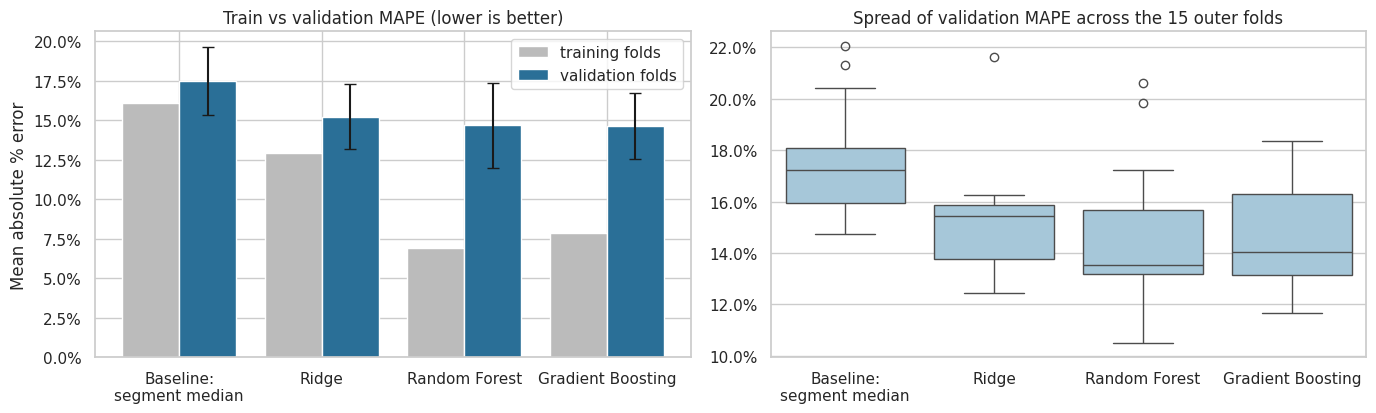

In [18]:
names = list(cv_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
x = np.arange(len(names))
tr = [results.loc[n, "train MAPE"] for n in names]
va = [results.loc[n, "val MAPE"] for n in names]
sd = [results.loc[n, "val MAPE sd"] for n in names]
axes[0].bar(x - .2, tr, .4, label="training folds", color="#bbb")
axes[0].bar(x + .2, va, .4, yerr=sd, capsize=4, label="validation folds", color="#2a6f97")
axes[0].set_xticks(x, [n.replace("Baseline: ", "Baseline:\n") for n in names])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set(title="Train vs validation MAPE (lower is better)", ylabel="Mean absolute % error")
axes[0].legend()

box = pd.DataFrame({n: -cv_results[n]["test_MAPE"] for n in names})
sns.boxplot(data=box, ax=axes[1], color="#9ecae1")
axes[1].set_xticks(range(len(names)), [n.replace("Baseline: ", "Baseline:\n") for n in names])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set(title="Spread of validation MAPE across the 15 outer folds", ylabel="")
plt.tight_layout(); save(fig, "fig5_cv_results"); plt.show()

### Model complexity: under- and over-fitting
Validation curves vary one complexity parameter per model (5-fold CV, other settings fixed) and show training vs validation MAPE.

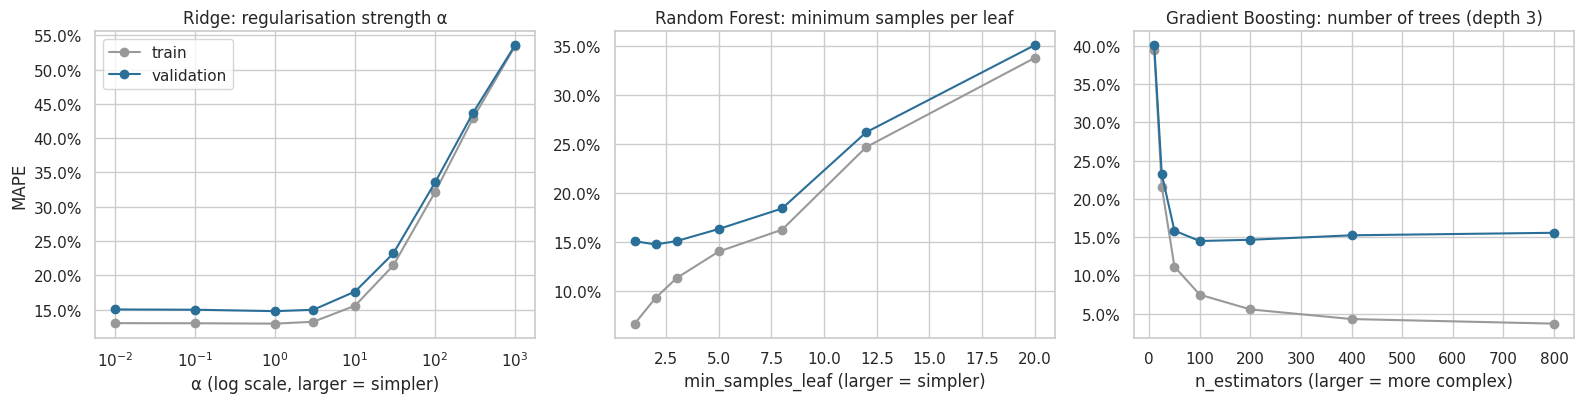

Ridge: regularisation strength α
            0.010      0.100      1.000      3.000      10.000     30.000     100.000    300.000    1,000.000
train          13.000     13.000     12.900     13.200     15.600     21.400     32.100     43.000     53.400
validation     15.000     15.000     14.800     15.000     17.600     23.200     33.500     43.700     53.600

Random Forest: minimum samples per leaf
               1      2      3      5      8      12     20
train       6.600  9.300 11.300 14.000 16.200 24.700 33.800
validation 15.100 14.700 15.100 16.300 18.400 26.200 35.100

Gradient Boosting: number of trees (depth 3)
              10     25     50     100    200    400    800
train      39.500 21.600 11.100  7.500  5.600  4.300  3.700
validation 40.100 23.200 15.800 14.500 14.700 15.200 15.600



In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
curves = [
    ("Ridge: regularisation strength α", log_target(Pipeline([("prep", preprocessor(True)), ("model", Ridge())])),
     "regressor__model__alpha", [0.01, 0.1, 1, 3, 10, 30, 100, 300, 1000], True, "α (log scale, larger = simpler)"),
    ("Random Forest: minimum samples per leaf", log_target(Pipeline([("prep", preprocessor(False)), ("model", RandomForestRegressor(n_estimators=200, max_features=0.66, random_state=SEED))])),
     "regressor__model__min_samples_leaf", [1, 2, 3, 5, 8, 12, 20], False, "min_samples_leaf (larger = simpler)"),
    ("Gradient Boosting: number of trees (depth 3)", log_target(Pipeline([("prep", preprocessor(False)), ("model", GradientBoostingRegressor(learning_rate=0.05, max_depth=3, subsample=0.8, random_state=SEED))])),
     "regressor__model__n_estimators", [10, 25, 50, 100, 200, 400, 800], False, "n_estimators (larger = more complex)"),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
curve_data = {}
for ax, (title, est, param, grid, logx, xlabel) in zip(axes, curves):
    tr, va = validation_curve(est, X, y, param_name=param, param_range=grid, cv=kf,
                              scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    tr, va = -tr.mean(1), -va.mean(1)
    curve_data[title] = pd.DataFrame({"train": tr, "validation": va}, index=grid)
    ax.plot(grid, tr, "o-", color="#999", label="train")
    ax.plot(grid, va, "o-", color="#2a6f97", label="validation")
    if logx: ax.set_xscale("log")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set(title=title, xlabel=xlabel)
axes[0].set_ylabel("MAPE"); axes[0].legend()
plt.tight_layout(); save(fig, "fig6_complexity"); plt.show()
for t, d in curve_data.items():
    print(t); print((d * 100).round(1).T.to_string()); print()

### What the cross-validation shows

**All three models clearly beat the rule of thumb.** The segment-median baseline (what an agent might do: "Bondi 2-beds go for about X") has a validation MAPE of 17.5%. The models reach 14.6–15.2%, MAE improves from $285k to $228–246k, and Ridge beats the baseline in 14 of 15 folds.

**Between the models, the differences are within the noise.** Gradient Boosting (14.6%) and Random Forest (14.7%) are nominally best and Ridge (15.2%) close behind, but the fold-to-fold standard deviation is about ±2%. The paired comparison on identical splits shows Gradient Boosting beating Ridge in only 7 of 15 folds. What does separate them is the **size of the biggest misses**: Gradient Boosting's RMSE ($352k) is about 9% lower than Ridge's ($388k), so it makes fewer very large dollar errors, which happen on expensive Bondi and Parramatta houses.

**Over- and under-fitting.**
- *Ridge* has a small train–validation gap (12.9% vs 15.2%). It slightly **underfits**: its linear form cannot bend to every segment, but it does not memorise the data. The validation curve is flat for α ≤ 3 and then rises steeply (53% at α = 1000), where heavy regularisation shrinks the model towards predicting the average.
- *Random Forest* has the largest gap (6.9% train vs 14.7% validation): fully grown trees almost memorise 94 training rows. Averaging 300 decorrelated trees keeps validation error low anyway, and the curve shows validation error barely changing between 1 and 3 samples per leaf while training error rises. Variance is controlled by averaging rather than by limiting tree size.
- *Gradient Boosting* shows the classic complexity curve: with 10–25 trees it **underfits** (40% and 23% validation MAPE), the optimum is around 100 depth-3 trees (14.5%), and beyond that training error keeps falling (3.7% at 800 trees) while validation error creeps back up (15.6%). That is **overfitting**. Nested CV picked either depth-2 with 300 trees or depth-3 with 100 trees, two settings of similar overall complexity.

**Hyperparameter stability.** Ridge picked α = 1 in 9 of 15 outer folds, a stable choice. The tree models' choices varied between folds, another sign that 118 sales are a small sample for flexible models.

**Where errors concentrate (table above).** *Penrith units* are easiest (7–10% MAPE): a homogeneous stock of recent apartments. *Bondi units* are hardest (20–24%): they range from 1-bed walk-ups with no parking to top-floor ocean-view apartments in new buildings, and none of that is in the data. Notably, for *Penrith houses* the simple segment median (10.8%) beats every model, because when a segment is homogeneous, extra features mainly add noise.

In [20]:
# Out-of-fold predictions (5-fold, each fold tuned by its own inner CV) for per-suburb errors and Part 4
oof_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof = {name: cross_val_predict(model, X, y, cv=oof_cv) for name, model in models.items()}
oof["Baseline: segment median"] = cross_val_predict(SegmentMedian(), X, y, cv=oof_cv)

by_suburb = pd.DataFrame({
    name: pd.Series(np.abs(pred - y) / y, index=df.index).groupby([df.suburb, df.dwelling_class]).mean()
    for name, pred in oof.items()})
by_suburb.insert(0, "n", df.groupby(["suburb", "dwelling_class"]).size())
by_suburb.style.format({c: "{:.1%}" for c in by_suburb.columns if c != "n"})

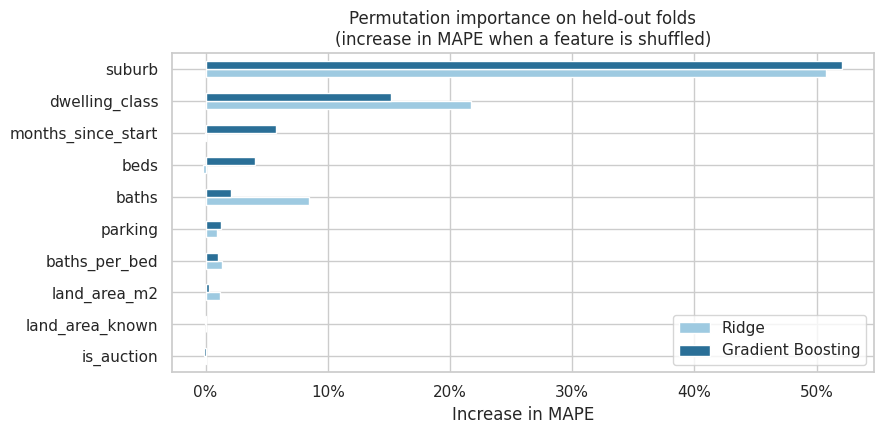

,Ridge (MAPE +pp),Gradient Boosting (MAPE +pp)
suburb,50.760,52.090
dwelling_class,21.750,15.150
months_since_start,-0.090,5.790
beds,-0.170,4.050
baths,8.440,2.080
parking,0.900,1.280
baths_per_bed,1.330,1.000
land_area_m2,1.190,0.270
land_area_known,0.040,-0.010
is_auction,-0.070,-0.100


In [21]:
# Which inputs matter? Permutation importance measured on held-out folds of the Ridge and Gradient Boosting models.
from sklearn.inspection import permutation_importance

def heldout_importance(estimator, n_repeats=10):
    imps = []
    for k, (tr_idx, te_idx) in enumerate(KFold(5, shuffle=True, random_state=SEED).split(X)):
        est = sklearn.base.clone(estimator).fit(X.iloc[tr_idx], y[tr_idx])
        r = permutation_importance(est, X.iloc[te_idx], y[te_idx], n_repeats=n_repeats,
                                   scoring="neg_mean_absolute_percentage_error", random_state=SEED)
        imps.append(pd.Series(r.importances_mean, index=X.columns))
    return pd.concat(imps, axis=1).mean(axis=1)

best_ridge = log_target(Pipeline([("prep", preprocessor(True)), ("model", Ridge(alpha=1))]))
best_gb = log_target(Pipeline([("prep", preprocessor(False)), ("model", GradientBoostingRegressor(
    n_estimators=300, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=SEED))]))
imp = pd.DataFrame({"Ridge": heldout_importance(best_ridge), "Gradient Boosting": heldout_importance(best_gb)})
imp = imp.sort_values("Gradient Boosting")

fig, ax = plt.subplots(figsize=(9, 4.5))
imp.plot.barh(ax=ax, color=["#9ecae1", "#2a6f97"])
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(title="Permutation importance on held-out folds\n(increase in MAPE when a feature is shuffled)", xlabel="Increase in MAPE")
plt.tight_layout(); save(fig, "fig7_importance"); plt.show()
(imp.sort_values("Gradient Boosting", ascending=False) * 100).round(2).rename(columns=lambda c: c + " (MAPE +pp)")

### Were the three initial hypotheses right?
Permutation importance, measured on held-out folds, ranks the inputs by how much MAPE worsens when each is shuffled:

- **Suburb** dominates (+51 to +52 percentage points of MAPE in both models). ✔ Hypothesis 1 confirmed.
- **Dwelling class** is clearly second (+15 to +22 pp). ✔ Hypothesis 2 confirmed.
- **Bedrooms:** ✔/✘ partly. In Gradient Boosting it is the 4th most important input (+4 pp). In Ridge, shuffling bedrooms alone barely matters, because bedrooms, bathrooms and baths-per-bed carry overlapping size information and Ridge leans on bathrooms (+8 pp) instead. "Size" as a concept matters, as hypothesised, but the model can get it from several correlated columns.
- **Land area** contributes little (+0.3 to +1.2 pp). This is not because land doesn't matter (Part 4 shows it does) but because 60% of values are missing and only a handful of large blocks exist.
- **Sale method** contributes nothing measurable.
- **Sale date** is a warning sign: Gradient Boosting uses it (+5.8 pp) although the within-segment trend is flat. As noted in Part 2, older records are disproportionately houses, so the date partly acts as a proxy for composition. That is a data artefact the model may wrongly rely on, and a reason to collect a more evenly spread sample.

## 3.3 Expectations revisited, and recommendation

| My prediction | Result |
|---|---|
| Ridge would be very competitive | **Supported.** Within 0.6 pp MAPE of the best model and statistically indistinguishable. |
| Random Forest would be slightly best | **Partly.** Nominally second (14.7% vs 14.6%); a tie with Gradient Boosting in practice (7 of 15 folds each way). |
| Gradient Boosting would overfit most | **Not supported.** Its train–validation gap (6.7 pp) is smaller than the Random Forest's (7.8 pp), and nested CV kept its complexity in check. |

**Recommendation: Gradient Boosting**, with Ridge as a credible alternative. Accuracy alone does not decide it, since the three are statistically tied on MAPE. I choose Gradient Boosting because:
1. it has the lowest MAE ($228k) and, most importantly for an agency, the **lowest RMSE ($352k)**, so it makes fewer very large dollar misses on high-value properties;
2. it is clearly better than Ridge on the hardest high-value segments (Parramatta houses 13.2% vs 17.9%; Bondi units 19.6% vs 21.6%);
3. nested CV shows its complexity can be controlled with shallow trees and a low learning rate.

The cost is interpretability and extrapolation. Ridge gives coefficients an agent can read, and Gradient Boosting cannot predict beyond the price range it has seen. The app mitigates the second point by warning when inputs fall outside the training range, and by always showing a likely price range rather than a single number.

---
# Part 4 — Investigating prediction failures
The five largest **absolute** errors from the recommended model's out-of-fold predictions (each property predicted by a model that never saw it).

In [22]:
best_name = "Gradient Boosting"  # recommended in Part 3
err = df[["suburb", "address", "dwelling_class", "property_type", "beds", "baths", "parking", "area_m2", "sale_method", "sold_date", "price", "url"]].copy()
err["predicted"] = oof[best_name]
err["error"] = err.predicted - err.price
err["abs_error"] = err.error.abs()
err["pct_error"] = err.error / err.price
seg_stats = df.groupby(["suburb", "dwelling_class"]).price.agg(seg_median="median", seg_n="count")
err = err.join(seg_stats, on=["suburb", "dwelling_class"])

top5 = err.nlargest(5, "abs_error")
show = top5[["suburb", "address", "property_type", "beds", "baths", "parking", "area_m2", "price", "predicted", "error", "pct_error", "seg_median", "seg_n"]]
display(show.style.format({"price": "${:,.0f}", "predicted": "${:,.0f}", "error": "${:+,.0f}",
                           "pct_error": "{:+.1%}", "seg_median": "${:,.0f}", "area_m2": "{:.0f}"}))

print("For comparison, the five largest percentage errors:")
display(err.reindex(err.pct_error.abs().nlargest(5).index)[["suburb", "address", "property_type", "beds", "price", "predicted", "pct_error"]]
        .style.format({"price": "${:,.0f}", "predicted": "${:,.0f}", "pct_error": "{:+.1%}"}))

,suburb,address,property_type,beds,baths,parking,area_m2,price,predicted,error,pct_error,seg_median,seg_n
70,Bondi,344 Birrell Street,House,5,3,1.000000,nan,"$5,860,000","$3,415,357","$-2,444,643",-41.7%,"$4,050,000",17
69,Bondi,62 Watson Street,House,3,2,1.000000,nan,"$3,300,000","$4,919,059","$+1,619,059",+49.1%,"$4,050,000",17
13,Bondi,5601/34 Wellington Street,Apartment / Unit / Flat,2,2,1.000000,nan,"$2,600,000","$1,608,309","$-991,691",-38.1%,"$1,520,000",21
42,Parramatta,124 Thomas Street,House,3,1,1.000000,739,"$2,300,000","$1,362,174","$-937,826",-40.8%,"$1,582,500",18
81,Bondi,11 Stephen Street,House,3,1,1.000000,nan,"$4,100,000","$3,208,000","$-892,000",-21.8%,"$4,050,000",17


For comparison, the five largest percentage errors:


,suburb,address,property_type,beds,price,predicted,pct_error
18,Bondi,7/162 Bondi Road,Apartment / Unit / Flat,1,"$650,000","$989,031",+52.2%
1,Parramatta,1404/1-3 Valentine Avenue,Apartment / Unit / Flat,1,"$320,000","$481,581",+50.5%
69,Bondi,62 Watson Street,House,3,"$3,300,000","$4,919,059",+49.1%
104,Penrith,4/151 Stafford Street,Villa,3,"$735,000","$1,045,684",+42.3%
70,Bondi,344 Birrell Street,House,5,"$5,860,000","$3,415,357",-41.7%


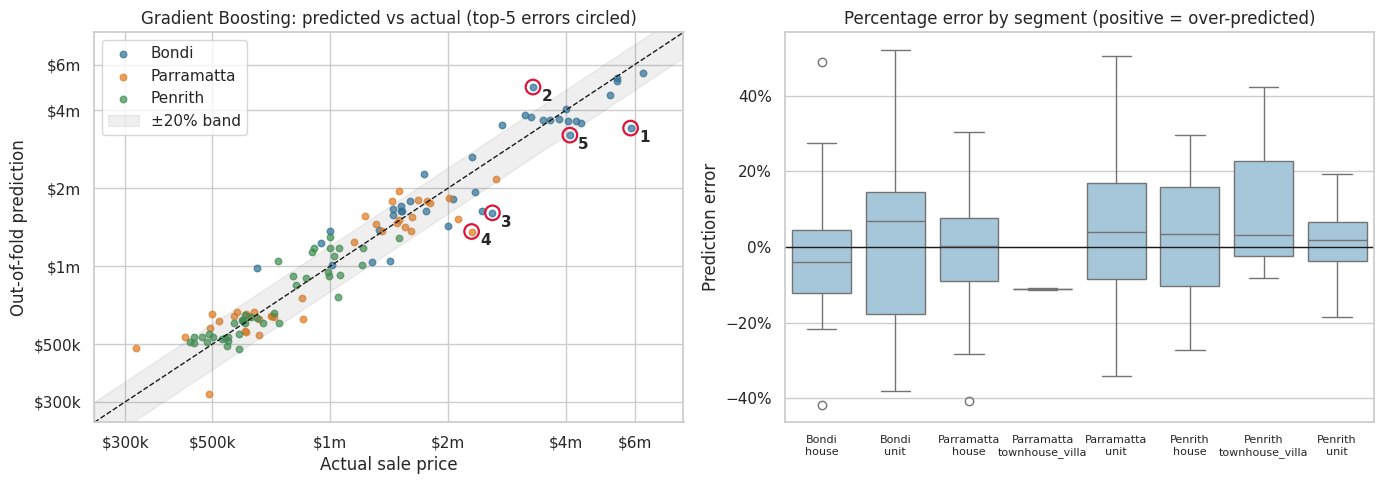

Share of properties predicted within ±10% / ±20%: 45% / 76%


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for sub in SUBURB_ORDER:
    d = err[err.suburb == sub]
    ax.scatter(d.price, d.predicted, s=22, alpha=.7, color=SUBURB_COLORS[sub], label=sub)
lims = [2.5e5, 8e6]
ax.plot(lims, lims, "k--", lw=1)
ax.fill_between(lims, [l * .8 for l in lims], [l * 1.2 for l in lims], color="grey", alpha=.12, label="±20% band")
for i, (_, r) in enumerate(top5.iterrows(), 1):
    ax.annotate(str(i), (r.price, r.predicted), xytext=(6, -10), textcoords="offset points", fontsize=11, weight="bold")
    ax.scatter(r.price, r.predicted, s=110, facecolors="none", edgecolors="crimson", lw=1.6)
price_axis(ax, "x"); price_axis(ax, "y")
ax.set(xlim=lims, ylim=lims, xlabel="Actual sale price", ylabel="Out-of-fold prediction",
       title=f"{best_name}: predicted vs actual (top-5 errors circled)")
ax.legend(loc="upper left")

seg_err = err.assign(segment=err.suburb + "\n" + err.dwelling_class)
sns.boxplot(data=seg_err, x="segment", y="pct_error", ax=axes[1], color="#9ecae1",
            order=sorted(seg_err.segment.unique()))
axes[1].axhline(0, color="k", lw=1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set(title="Percentage error by segment (positive = over-predicted)", xlabel="", ylabel="Prediction error")
axes[1].tick_params(axis="x", labelsize=8)
plt.tight_layout(); save(fig, "fig8_errors"); plt.show()

print("Share of properties predicted within ±10% / ±20%:",
      f"{(err.pct_error.abs() <= .10).mean():.0%} / {(err.pct_error.abs() <= .20).mean():.0%}")

## 4.1 The five largest errors

To explain each case, I opened the individual Domain listing and read the agent's description.

**1. 344 Birrell St, Bondi: sold $5.86m, predicted $3.42m (−$2.44m, −42%).** A *newly completed* 5-bed family home with a north-to-rear aspect near the beach. The model knows it has 5 bedrooms and 3 bathrooms but not that it is brand new, and only three other Bondi houses in the data have 5 or more bedrooms. Tree ensembles cannot predict above the range of similar training examples, so the prediction is pulled towards the typical Bondi house.

**2. 62 Watson St, Bondi: sold $3.30m, predicted $4.92m (+$1.62m, +49%).** The only large *over*-prediction among the five. Domain files it under "House", but the agent describes a semi-detached character home mixing original features with updates. My dwelling classes merge semis with freestanding houses, so the model treats it like a freestanding Bondi house. Its recent sale date and auction sale may push the prediction up further (the date effect noted in Part 3). *(The listing page now shows the pre-auction version; the $3.3m result comes from Domain's sold results page.)*

**3. 5601/34 Wellington St, Bondi: sold $2.60m, predicted $1.61m (−$0.99m, −38%).** A top-floor, north-facing 2-bed apartment with harbour and beach outlooks in a new luxury building (*The Moreton*). Views, floor level and building age drive this price, and none of them are in the data. For the model it is "a 2-bed, 2-bath Bondi unit".

**4. 124 Thomas St, Parramatta: sold $2.30m, predicted $1.36m (−$0.94m, −41%).** Marketed as a *development site* in original condition: 739 m² beside the Parramatta River, walking distance to the CBD. The buyer paid for land and redevelopment potential, not for a 3-bed, 1-bath house. The land area was in the data, but with land size missing for most houses the model barely uses it, and zoning and riverside position are not captured at all.

**5. 11 Stephen St, Bondi: sold $4.10m, predicted $3.21m (−$0.89m, −22%).** A *freestanding* original cottage held by one family since 1965, in a leafy cul-de-sac. The model marks it down for having only one bathroom, but buyers paid for a freestanding block in Bondi and the chance to renovate. The single bathroom signals renovation potential, not low value.

**The pattern.** Four of the five are *under*-predictions at the top of the market, and four are in Bondi. In every case the price is driven by something absent from the data: newness or condition, views and floor level, development potential and zoning, or freestanding versus attached. Large dollar errors naturally fall on expensive properties. Ranked by *percentage* error, the worst cases are cheap and unusual instead: the Mantra hotel apartment in Parramatta (+50%), a 1-bed Bondi walk-up with no parking (+52%) and a Penrith villa from a class with only 5 examples (+42%). Overall, 45% of properties are predicted within ±10% and 76% within ±20%.

## 4.2 Limitations and missing information

**Information that would most improve predictions:**
- internal floor area (bedrooms are a crude proxy) and complete land size;
- condition, age and renovation status ("newly completed", "original condition");
- views, aspect and floor level for apartments;
- zoning and development potential;
- freestanding vs semi-detached vs terrace;
- exact location within the suburb (distance to beach, station, river);
- strata levies and building quality;
- the agent's description text, which captured almost every one of the failure explanations above.

**When to treat predictions with caution:**
- prestige, unique or brand-new homes;
- development sites and very large blocks;
- serviced or hotel apartments, and retirement-village units (excluded entirely);
- rare dwelling types (villas, dual occupancies) and inputs outside the training range (e.g. 6+ bedrooms);
- suburbs other than these three;
- sale dates well outside Sep 2025 – Sep 2026, or a market that moves quickly.

**Are some properties inherently harder to model?** Yes. Homogeneous stock, like the recent Penrith apartment developments, is predictable from a few features (7–10% error). Expensive, heterogeneous stock, like Bondi houses and Bondi units, is not, because its value depends on qualities that are hard to quantify (character, views, position) and there are fewer comparable sales. Unusual assets (development sites, hotel units, dual occupancies) are hard for any comparable-sales approach, human or machine, which is why professional valuers inspect them.

---
# Part 5 — Final model, deployment and reflection

## 5.1 Train the final model on all data and save it for the app
The recommended model is refitted on all 118 sales, with its hyperparameters chosen by 5-fold CV on the full dataset. Alongside the model, I save metadata the app needs to be honest about uncertainty: the cross-validated error, the empirical spread of out-of-fold errors (used to show a likely price range), and the range of each input seen in training (used to warn when a user asks about something the model has never seen).

In [24]:
final_search = sklearn.base.clone(models[best_name]).fit(X, y)
final_model = final_search.best_estimator_
print("Final hyperparameters:", {k.split("__")[-1]: v for k, v in final_search.best_params_.items()})

# Likely range: 10th and 90th percentiles of out-of-fold log errors (log(actual) - log(predicted))
log_resid = np.log(y) - np.log(oof[best_name])
q10, q90 = np.quantile(log_resid, [0.10, 0.90])

meta = {
    "model_name": best_name,
    "trained_on": len(df),
    "trained_at": "2026-10-01",
    "sale_dates": [str(df.sold_date.min().date()), str(df.sold_date.max().date())],
    "cv_mape": float(results.loc[best_name, "val MAPE"]),
    "cv_mae": float(results.loc[best_name, "val MAE"]),
    "interval_log_quantiles": [float(q10), float(q90)],
    "hyperparameters": {k.split("__")[-1]: v for k, v in final_search.best_params_.items()},
    "ranges": {c: [float(X[c].min()), float(X[c].max())] for c in ["beds", "baths", "parking", "land_area_m2"]},
    "segment_counts": {f"{s}_{c}": int(n) for (s, c), n in df.groupby(["suburb", "dwelling_class"]).size().items()},
    "sklearn_version": sklearn.__version__,
}
Path("app/model").mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, "app/model/house_price_model.joblib")
Path("app/model/model_meta.json").write_text(json.dumps(meta, indent=2))
print(json.dumps({k: meta[k] for k in ["model_name", "trained_on", "cv_mape", "interval_log_quantiles"]}, indent=2))

Final hyperparameters: {'max_depth': 2, 'n_estimators': 300}
{
  "model_name": "Gradient Boosting",
  "trained_on": 118,
  "cv_mape": 0.14620813692544213,
  "interval_log_quantiles": [
    -0.23778415663989297,
    0.2074059418934121
  ]
}


In [25]:
# Smoke test: reload the saved model exactly as the app does and price two example properties
loaded = joblib.load("app/model/house_price_model.joblib")
examples = pd.DataFrame([
    {"suburb": "Penrith", "property_type": "House", "address": "", "beds": 3, "baths": 1, "parking": 1,
     "area_m2": 600, "sale_method": "private treaty", "sold_date": "2026-09-15"},
    {"suburb": "Bondi", "property_type": "Apartment / Unit / Flat", "address": "", "beds": 2, "baths": 1, "parking": 1,
     "area_m2": None, "sale_method": "auction", "sold_date": "2026-09-15"},
])
pred = loaded.predict(hf.engineer_features(examples))
for (_, r), p in zip(examples.iterrows(), pred):
    print(f"{r.suburb} {r.property_type}, {r.beds} bed: {money(p)}  (likely range {money(p*np.exp(q10))} to {money(p*np.exp(q90))})")

Penrith House, 3 bed: $866,682  (likely range $683,268 to $1,066,436)
Bondi Apartment / Unit / Flat, 2 bed: $1,814,109  (likely range $1,430,194 to $2,232,229)


## 5.2 The web application
The app (`app/app.py`) is a small **Flask** application. It imports the same `housing_features.py` used here, loads `house_price_model.joblib`, and offers two ways in:

1. **Single property form.** Choose suburb and property type, enter bedrooms, bathrooms, parking, optional land size, sale method and expected sale month. The app returns the predicted price, a likely range (10th–90th percentile of the model's cross-validated errors), and warnings when inputs fall outside what the model was trained on.
2. **CSV upload.** Upload a CSV with the same columns (a template is downloadable from the app) to price many properties at once. Results show on screen and download as CSV.

Run it with `python app/app.py` and open http://127.0.0.1:5000. Screenshots and full instructions are in the report and `README.md`.

## 5.3 Reflection on the full workflow

**Key lessons.**
- *Data work dominated.* Collection and cleaning took longer than modelling and changed the results more: correcting dwelling classes and adding the suburb × type interaction improved MAPE by about 4 points, while choosing between three model families changed it by less than 1 point.
- *A baseline keeps you honest.* A one-line segment-median rule reaches 17.5% MAPE, so the real value added by machine learning here is roughly 3 points, and in Penrith houses it is zero.
- *Small data calls for careful evaluation.* With 118 sales, a single train/test split would have given noisy and possibly misleading rankings. Repeated, nested k-fold CV and a paired comparison showed that the models are tied, which is itself a useful finding.

**Challenges.**
- *Collection:* about half of all sales have withheld prices; search pages sometimes disagreed with listing pages, so records had to be verified; Domain mislabels some property types; areas mix floor area and site area.
- *Preprocessing:* duplicated listings, leasehold retirement units, and deciding to keep genuine outliers rather than tidy them away.
- *Feature engineering:* most useful features (condition, views, zoning) were simply unavailable; land area was too incomplete to help much; time was confounded with sample composition.
- *Modelling and evaluation:* flexible models nearly memorise a small training set, so hyperparameters had to be tuned inside the CV loop to keep the reported errors unbiased.

**Performance vs practical deployment.** The most accurate model is not automatically the best tool. Gradient Boosting was chosen for fewer large misses, but Ridge would be easier to explain to a vendor, behave more predictably on unusual inputs, and be trivial to retrain. For deployment, the features must be computed *identically* in training and in the app (hence the shared `housing_features.py`), the scikit-learn version must match the one used to save the model, and the app must communicate uncertainty (a likely range and out-of-range warnings) rather than a single falsely precise number.

**Bias, fairness and limitations.** The sample over-represents fully disclosed sales and, by design, houses. It covers only three suburbs and 13 months, so it must not be used elsewhere. The model systematically under-values the top end and over-values the cheapest unusual units. If used to set asking prices or lending decisions, that pattern would compress price differences, disadvantaging sellers of premium homes and buyers of atypical cheap units. Suburb is the strongest feature, and suburbs correlate with income and demographic composition, so a valuation model can reinforce existing geographic price gaps. Predictions should support, not replace, a valuer's judgement.

**What I would do with more data, resources and time.**
- Use the **NSW Valuer General's bulk property sales data**, which records every settled sale *including* those with withheld prices, removing the selection bias and supplying thousands of records over several years.
- Add more suburbs so location can be modelled continuously (distance to CBD, beach and station from geocoded addresses).
- Collect the **agent descriptions** and apply text features (keywords such as "renovated", "original", "development", "views", or sentence embeddings), and possibly listing photos.
- Add floor area, strata levies, school catchments and zoning.
- Use proper prediction intervals (quantile regression or conformal prediction) instead of empirical error percentiles.
- With more computing power, run a wider hyperparameter search with more CV repeats, and try CatBoost and model stacking.

## GenAI acknowledgement
Claude (Anthropic) was used as an assistant in this project to help read Domain sold-listing pages and transcribe them into the dataset (records were spot-checked against the original listing pages), to draft and debug the Python code for the notebook and Flask app, and to draft explanatory text. All design choices, results and interpretations were reviewed by me, and I am responsible for the final submission.